In [1]:
import pandas as pd
dta = pd.read_csv('../data/complaints.csv')
dta.shape


(11522175, 18)

In [ ]:
#lowercase column names and replace spaces with underscores
dta.columns = dta.columns.str.lower().str.replace(' ', '_')
dta.head(2)

,date_received,product,sub-product,issue,sub-issue,consumer_complaint_narrative,company_public_response,company,state,zip_code,tags,consumer_consent_provided?,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response?,consumer_disputed?,complaint_id
0,2020-07-06,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,346XX,NaN,Other,Web,2020-07-06,Closed with explanation,Yes,NaN,3730948
1,2025-10-14,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information is missing that should be on the r...,NaN,NaN,"EQUIFAX, INC.",TX,75062,NaN,NaN,Web,2025-10-14,In progress,Yes,NaN,16558024


In [ ]:
dta.head(2)
#convert date received to datetime
dta['date_received'] = pd.to_datetime(dta['date_received'])
#convert date_recieved to date only
dta['date_received'] = dta['date_received'].dt.date
dta['date_received'].head(2)


0    2020-07-06
1    2025-10-14
Name: date_received, dtype: object

In [ ]:
#keep only the lat 3 years of data
dta = dta[dta['date_received'] >= pd.to_datetime('2024-11-01').date()]
print(dta.shape)
dta.head(2)


(4869958, 18)


,date_received,product,sub-product,issue,sub-issue,consumer_complaint_narrative,company_public_response,company,state,zip_code,tags,consumer_consent_provided?,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response?,consumer_disputed?,complaint_id
1,2025-10-14,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information is missing that should be on the r...,NaN,NaN,"EQUIFAX, INC.",TX,75062,NaN,NaN,Web,2025-10-14,In progress,Yes,NaN,16558024
2,2025-10-10,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"EQUIFAX, INC.",GA,30341,NaN,NaN,Web,2025-10-10,In progress,Yes,NaN,16507707


In [ ]:
dta = dta.loc[dta.company.isin(['CAPITAL ONE FINANCIAL CORPORATION',
                          'JPMORGAN CHASE & CO.',
                          "Block, Inc.",
                          "WELLS FARGO & COMPANY",
                          "BANK OF AMERICA, NATIONAL ASSOCIATION",
                          "CITIBANK, N.A.",
                          "Early Warning Services, LLC",
                          "NAVY FEDERAL CREDIT UNION",
                          "SYNCHRONY FINANCIAL",
                          "AMERICAN EXPRESS COMPANY",
                          "DISCOVER BANK",
                          "Paypal Holdings, Inc",
                          "U.S. BANCORP",
                          "Chime Financial Inc",
                          "ALLY FINANCIAL INC."]), :]

In [ ]:
dta.company.value_counts()

company
Block, Inc.                              45616
CAPITAL ONE FINANCIAL CORPORATION        30517
Early Warning Services, LLC              23719
JPMORGAN CHASE & CO.                     21474
NAVY FEDERAL CREDIT UNION                17514
CITIBANK, N.A.                           16936
WELLS FARGO & COMPANY                    16860
BANK OF AMERICA, NATIONAL ASSOCIATION    16483
SYNCHRONY FINANCIAL                      11609
AMERICAN EXPRESS COMPANY                  9465
DISCOVER BANK                             8230
Paypal Holdings, Inc                      5864
Chime Financial Inc                       5599
ALLY FINANCIAL INC.                       5095
U.S. BANCORP                              4734
Name: count, dtype: int64

In [ ]:
#count null values in each column
print(dta.shape)
dta.isnull().sum()

(239715, 18)


date_received                        0
product                              0
sub-product                          0
issue                                0
sub-issue                        73456
consumer_complaint_narrative    105864
company_public_response         160277
company                              0
state                             1237
zip_code                             0
tags                            211765
consumer_consent_provided?       36372
submitted_via                        0
date_sent_to_company                 0
company_response_to_consumer         0
timely_response?                     0
consumer_disputed?              239715
complaint_id                         0
dtype: int64

In [ ]:
dta.head(2)
w_narr = dta.loc[dta.consumer_complaint_narrative.notnull(), :]
print(w_narr.shape)

(133851, 18)


In [ ]:
w_narr['narr_length'] = w_narr.consumer_complaint_narrative.str.len()
w_narr.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
#drop narrative gt 4930 characters
w_narr = w_narr.loc[w_narr.narr_length <= 4930, :]
print(w_narr.shape)

(132512, 19)


C:\Users\whdgu\AppData\Local\Temp\ipykernel_34668\3828107313.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  w_narr['narr_length'] = w_narr.consumer_complaint_narrative.str.len()


In [ ]:
#Product/subproduct value counts
w_narr[['product', 'sub-product']].value_counts()
#products / subproducts with less than 1%  complaints
product_counts = w_narr[['product', 'sub-product']].value_counts()
#filter out products with less than 2% complaints
product_counts = product_counts[product_counts <= product_counts.sum() * 0.02]
rare_products = product_counts.index.tolist()
rare_products


In [ ]:
#remove rare products from w_narr
for product, subproduct in rare_products:
    w_narr = w_narr.loc[~((w_narr.product == product) & (w_narr['sub-product'] == subproduct)), :]
print(w_narr.shape)


In [ ]:
#check if gpu is available
import torch
print(torch.cuda.is_available())



In [6]:
#get embedding model from huggingface
from transformers import AutoTokenizer, AutoModel
#load models on gpu if available
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-miniLM-L6-v2")
model = AutoModel.from_pretrained("sentence-transformers/all-miniLM-L6-v2").to(device)
model = model.to(device)

#check model device
next(model.parameters()).device

device(type='cuda', index=0)

In [ ]:


def embed_text(text):
    #tokenize text
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True).to(device)
    #get model output
    with torch.no_grad():
        outputs = model(**inputs)
    #mean pooling
    embeddings = outputs.last_hidden_state.mean(dim=1)
    return embeddings.cpu().numpy()
#embed all narratives
import numpy as np
embeddings = []
batch_size = 32
for i in range(0, len(w_narr), batch_size):
    print(f"Processing batch {i//batch_size + 1}")
    batch_texts = w_narr['consumer_complaint_narrative'].iloc[i:i+batch_size].tolist()
    batch_embeddings = embed_text(batch_texts)
    embeddings.append(batch_embeddings)
embeddings = np.vstack(embeddings)
print(embeddings.shape)
#save embeddings to pickle file with complaint ids, product, subproduct, company
embeddings_dict = {
    'complaint_id': w_narr['complaint_id'].tolist(),
    'product': w_narr['product'].tolist(),
    'sub-product': w_narr['sub-product'].tolist(),
    'company': w_narr['company'].tolist(),
    'narrative': w_narr['consumer_complaint_narrative'].tolist(),
    'embeddings': embeddings
}
#write to pickle file
import pickle
with open('../data/complaint_embeddings.pkl', 'wb') as f:
    pickle.dump(embeddings_dict, f)
    












In [ ]:
#add complaint_id, date_received, company, and product, subproduct, narrative to embeddings dataframe
embeddings_df = pd.DataFrame(embeddings)
embeddings_df['complaint_id'] = w_narr['complaint_id'].values
embeddings_df['date_received'] = w_narr['date_received'].values
embeddings_df['company'] = w_narr['company'].values
embeddings_df['product'] = w_narr['product'].values
#embeddings_df['sub_product'] = w_narr['sub_product'].values
embeddings_df['consumer_complaint_narrative'] = w_narr['consumer_complaint_narrative'].values
embeddings_df.head(2)
#save embedding to pickle file
embeddings_df.to_pickle('../data/complaint_embeddings.pkl')


In [ ]:
#company value counts
w_narr.company.value_counts()

In [ ]:
from sklearn.utils import resample


N_SAMPLES = 25000 

if len(embeddings) > N_SAMPLES:
    embeddings_subset = resample(embeddings, n_samples=N_SAMPLES, random_state=442)
else:
    embeddings_subset = embeddings

Find the best threshold per product using silhouette score

In [ ]:
#cluster embeddings using agglomerative clustering
from sklearn.cluster import AgglomerativeClustering
#try different thresholds for clustering and see how many clusters are formed, get silhouette score
from sklearn.metrics import silhouette_score    
thresholds = [.75, 1, 2.0, 3.0,  4.0, 4.5, 5.0, 5.5, 6.0, 10, 15, 20, 25,28,30, 35,40,45,50]
silhouette_scores = pd.DataFrame()
for thresh in thresholds:
    clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=thresh)
    cluster_labels = clustering.fit_predict(embeddings_subset)
    n_clusters = len(set(cluster_labels))
    if n_clusters > 1 and n_clusters < len(embeddings_subset):
        sil_score = silhouette_score(embeddings_subset, cluster_labels)
        sil_score_dict = {'threshold': thresh, 'n_clusters': n_clusters, 'silhouette_score': sil_score}
        sil_score_df = pd.DataFrame([sil_score_dict])
        silhouette_scores = pd.concat([silhouette_scores, sil_score_df], ignore_index=True)

    else:
        sil_score = None
    print(f"Threshold: {thresh}, Number of clusters: {n_clusters}, Silhouette Score: {sil_score}")
#plot silhouette scores
import matplotlib.pyplot as plt
plt.plot(silhouette_scores['threshold'], silhouette_scores['silhouette_score'], marker='o')
plt.xlabel('Distance Threshold')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Distance Threshold')
plt.show()
# write to csv
silhouette_scores.to_csv('../data/silhouette_scores.csv', index=False)
#get the best threshold based on silhouette score
best_thresh = silhouette_scores.loc[silhouette_scores['silhouette_score'].idxmax(), 'threshold']
print(f"Best Threshold: {best_thresh}")



In [2]:
#for each product, cluster the embeddings using the best number of clusters
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np

data_dict = pd.read_pickle('../data/complaint_embeddings.pkl')
# Properly convert embeddings dict to DataFrame
embeddings_array = data_dict['embeddings']
embeddings_df = pd.DataFrame(embeddings_array)
embeddings_df['complaint_id'] = data_dict['complaint_id']
embeddings_df['product'] = data_dict['product']
embeddings_df['sub-product'] = data_dict['sub-product']
embeddings_df['company'] = data_dict['company']
embeddings_df['narrative'] = data_dict['narrative']

# Store the number of embedding columns before adding cluster column
n_embedding_cols = embeddings_array.shape[1]

best_thresh = pd.read_csv('output/best_distance_thresholds.csv')

for product in list(set(embeddings_df['product'])):
    product_mask = embeddings_df['product'] == product
    n_clusters = int(best_thresh.loc[best_thresh['product'] == product, 'num_clusters'].values[0])
    print(f"Clustering product: {product} with {product_mask.sum()} complaints into {n_clusters} clusters")
    
    # Get the indices and embeddings for this product
    if product_mask.sum() > 25000:
        # Sample for clustering
        sampled_indices = embeddings_df.loc[product_mask].sample(25000, random_state=442).index
        product_embeddings_sample = embeddings_df.loc[sampled_indices].iloc[:, :n_embedding_cols].values
        
        # Cluster the sample using n_clusters
        clustering = AgglomerativeClustering(n_clusters=n_clusters)
        cluster_labels_sample = clustering.fit_predict(product_embeddings_sample)
        
        # Assign cluster labels to sampled points
        embeddings_df.loc[sampled_indices, 'agglomerative_cluster'] = cluster_labels_sample
        
        # For remaining points, assign to nearest cluster using KNN
        remaining_mask = product_mask & ~embeddings_df.index.isin(sampled_indices)
        if remaining_mask.sum() > 0:
            remaining_embeddings = embeddings_df.loc[remaining_mask].iloc[:, :n_embedding_cols].values
            nn = NearestNeighbors(n_neighbors=1)
            nn.fit(product_embeddings_sample)
            distances, indices = nn.kneighbors(remaining_embeddings)
            remaining_cluster_labels = cluster_labels_sample[indices.flatten()]
            embeddings_df.loc[remaining_mask, 'agglomerative_cluster'] = remaining_cluster_labels
    else:
        # Cluster all points if under threshold using n_clusters
        product_embeddings = embeddings_df.loc[product_mask].iloc[:, :n_embedding_cols].values
        clustering = AgglomerativeClustering(n_clusters=n_clusters)
        cluster_labels = clustering.fit_predict(product_embeddings)
        embeddings_df.loc[product_mask, 'agglomerative_cluster'] = cluster_labels

#write embeddings_df with cluster labels to pickle file
embeddings_df.to_pickle('../data/complaint_embeddings_with_clusters.pkl')


Clustering product: Money transfer, virtual currency, or money service with 54312 complaints into 16 clusters
Clustering product: Prepaid card with 1751 complaints into 3 clusters
Clustering product: Debt or credit management with 205 complaints into 2 clusters
Clustering product: Checking or savings account with 31893 complaints into 26 clusters
Clustering product: Prepaid card with 1751 complaints into 3 clusters
Clustering product: Debt or credit management with 205 complaints into 2 clusters
Clustering product: Checking or savings account with 31893 complaints into 26 clusters
Clustering product: Debt collection with 4404 complaints into 3 clusters
Clustering product: Debt collection with 4404 complaints into 3 clusters
Clustering product: Mortgage with 1243 complaints into 2 clusters
Clustering product: Credit reporting or other personal consumer reports with 15246 complaints into 36 clusters
Clustering product: Mortgage with 1243 complaints into 2 clusters
Clustering product: Cre

In [20]:
#import embeeddings with cluster labels from pickle file
import pandas as pd
embeddings_df = pd.read_pickle('../data/complaint_embeddings_with_clusters.pkl')
embeddings_df.head(2)


,0,1,2,3,4,5,6,7,8,9,...,380,381,382,383,complaint_id,date_received,company,product,consumer_complaint_narrative,agglomerative_cluster
0,-0.370672,-0.297977,0.118031,0.151081,0.284094,-0.118132,0.145074,-0.163338,-0.204628,-0.348756,...,0.212616,-0.059139,0.534717,-0.120117,16179108,2025-09-25,WELLS FARGO & COMPANY,Credit reporting or other personal consumer re...,THESE 3 COMPANIES ARE ON MY CREDIT REPORT AND ...,24
1,-0.111187,-0.089718,0.415655,0.017798,0.136114,-0.181542,0.113605,-0.134354,-0.011274,-0.133676,...,0.269920,-0.069039,0.081852,-0.046670,15305109,2025-08-15,CAPITAL ONE FINANCIAL CORPORATION,Credit reporting or other personal consumer re...,"On XX/XX/scrub>, 2025 I received a text saying...",6


In [18]:
from name_clusters import sample_narratives_by_product_cluster, create_cluster_name

cluster_names= pd.DataFrame(columns=['product', 'agglomerative_cluster', 'cluster_name'])
for product, cluster in embeddings_df[['product', 'agglomerative_cluster']].drop_duplicates().itertuples(index=False):
    print(f"Processing product: {product}, cluster: {cluster}")
    sample_narratives = sample_narratives_by_product_cluster(embeddings_df, product, cluster, n_samples=10)
    cluster_name = create_cluster_name(sample_narratives)
    print(f"Cluster name: {cluster_name}")
    cluster_name_dict = {
        'product': product,
        'agglomerative_cluster': cluster,
        'cluster_name': cluster_name
    }
    cluster_names = pd.concat([cluster_names, pd.DataFrame([cluster_name_dict])], ignore_index=True)
cluster_names.head(2)
#save cluster names to csv
cluster_names.to_csv('output/cluster_names.csv', index=False)

Processing product: Credit reporting or other personal consumer reports, cluster: 24


Processing product: Credit reporting or other personal consumer reports, cluster: 24


KeyboardInterrupt: 

In [3]:
#import embeeddings with cluster labels from pickle file
import pandas as pd
#import if needed
if 'embeddings_df' not in locals():
    embeddings_df = pd.read_pickle('../data/complaint_embeddings_with_clusters.pkl')
embeddings_df.head(2)
#add cluster name column
cluster_names =pd.read_csv('output/cluster_names.csv')
#get dtsatnce threshold from cluster_column as the last part after underscore
cluster_names['distance_threshold'] = cluster_names['cluster_column'].apply(lambda x: float(x.split('_')[-1]))
#Filter cluster names to only include those with the best threshold per product
best_thresh = pd.read_csv('output/best_distance_thresholds.csv')
best_thresh
cluster_names = cluster_names.merge(best_thresh, left_on=['product', 'distance_threshold'], right_on=['product', 'best_distance_threshold'], how='inner', suffixes=('', '_best')).drop(columns=['cluster_column', 'best_distance_threshold'])
cluster_names.head(2)
#merge on product and cluster label
embeddings_df = embeddings_df.merge(cluster_names, left_on=['product', 'agglomerative_cluster'], right_on=['product', 'cluster_label'], how='left')
embeddings_df.head(2)

,0,1,2,3,4,5,6,7,8,9,...,product,sub-product,company,narrative,agglomerative_cluster,cluster_label,cluster_name,distance_threshold,num_clusters,silhouette
0,-0.370672,-0.297977,0.118031,0.151081,0.284094,-0.118132,0.145074,-0.163338,-0.204628,-0.348756,...,Credit reporting or other personal consumer re...,Credit reporting,WELLS FARGO & COMPANY,THESE 3 COMPANIES ARE ON MY CREDIT REPORT AND ...,35.0,35,**Inaccurate Credit Reporting Disputes**,20.0,36,0.032
1,-0.111187,-0.089718,0.415655,0.017798,0.136114,-0.181542,0.113605,-0.134354,-0.011274,-0.133676,...,Credit reporting or other personal consumer re...,Credit reporting,CAPITAL ONE FINANCIAL CORPORATION,"On XX/XX/scrub>, 2025 I received a text saying...",2.0,2,Unauthorized Account & Credit Report Errors,20.0,36,0.032


In [14]:
embeddings_df.columns[-12:]

Index([                           383,                 'complaint_id',
                      'date_received',                      'company',
                            'product', 'consumer_complaint_narrative',
              'agglomerative_cluster',                'cluster_label',
                       'cluster_name',           'distance_threshold',
                       'num_clusters',                   'silhouette'],
      dtype='object')

C:\Users\whdgu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\whdgu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\whdgu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


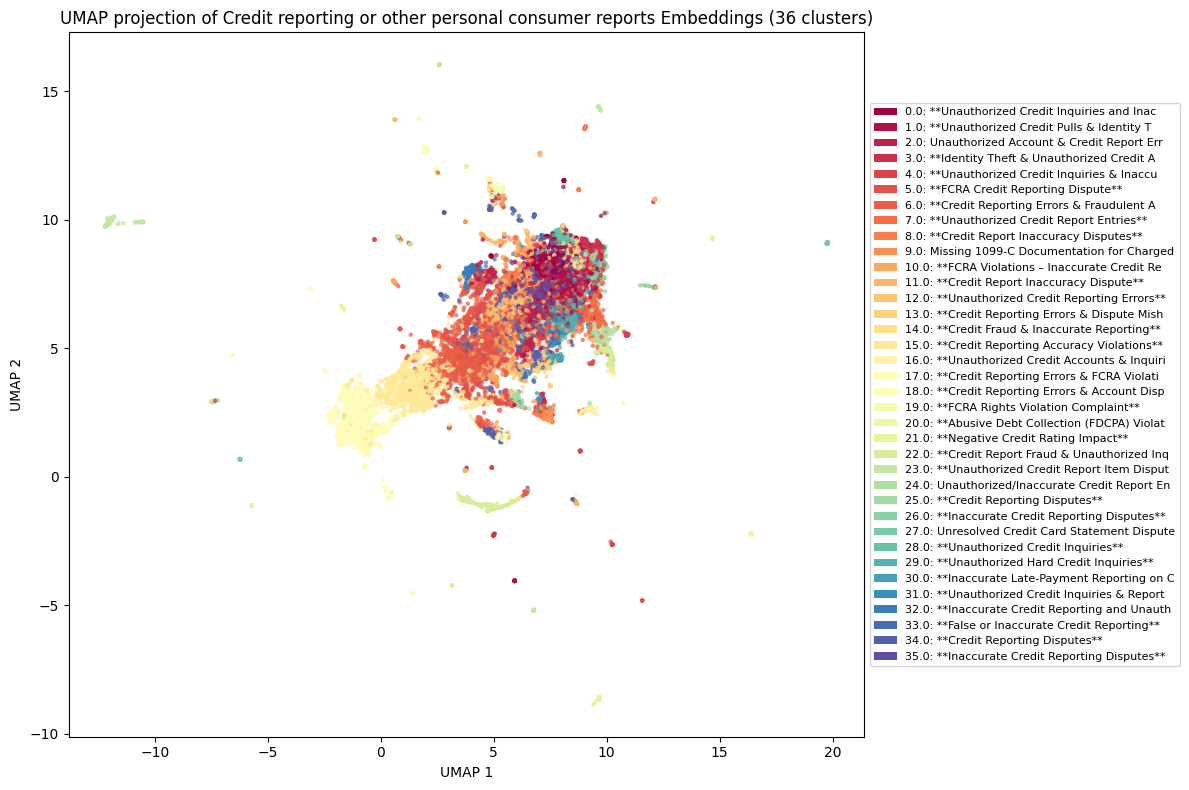

C:\Users\whdgu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


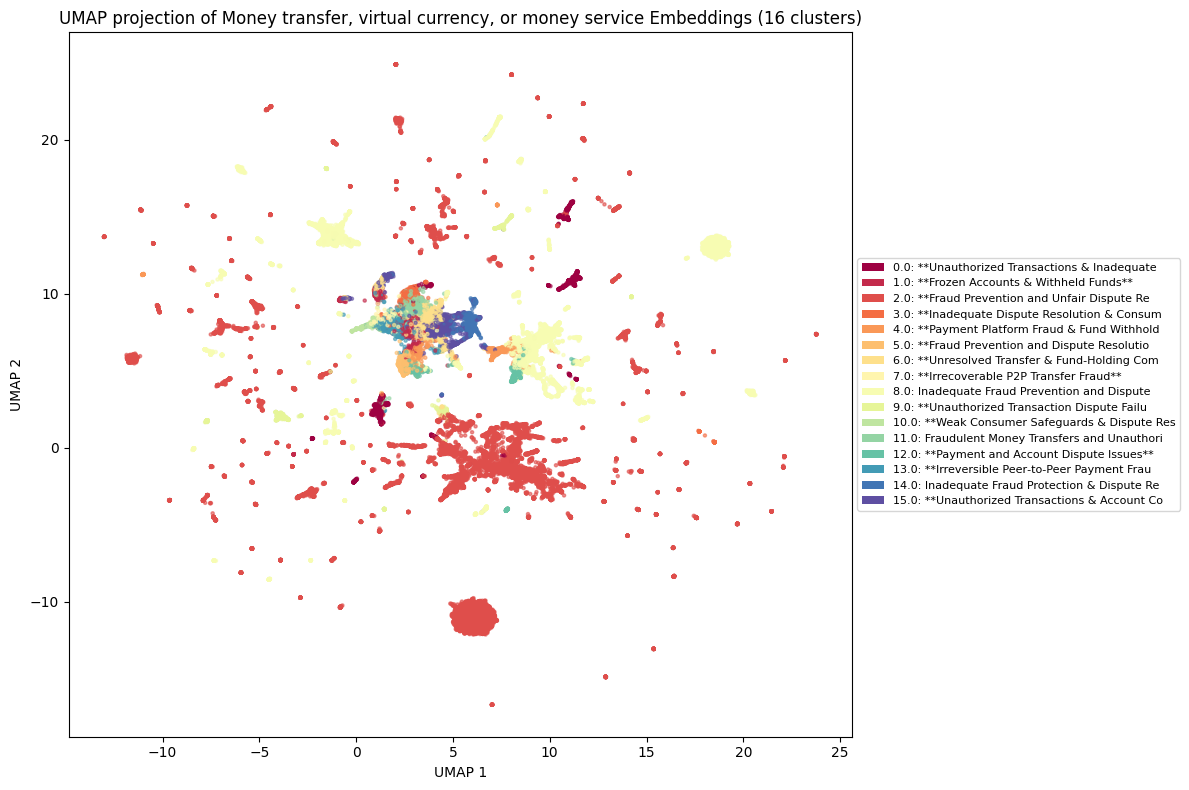

C:\Users\whdgu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


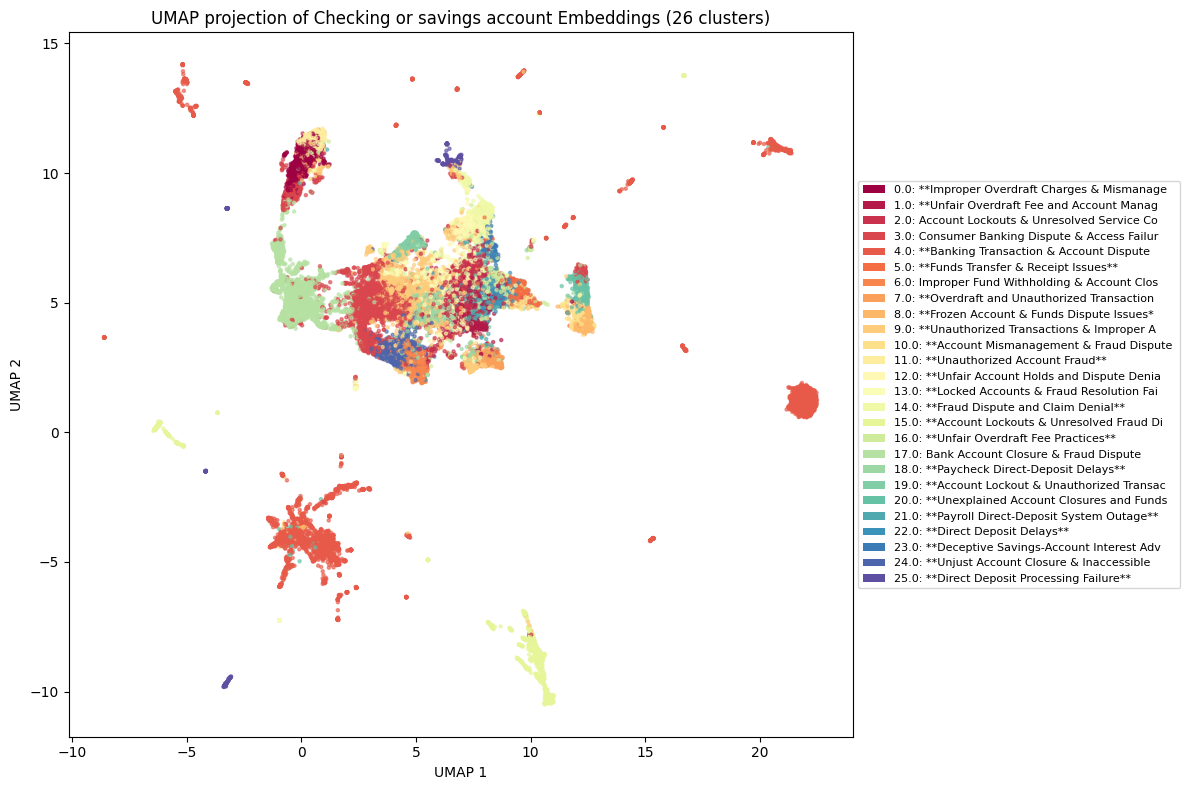

C:\Users\whdgu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


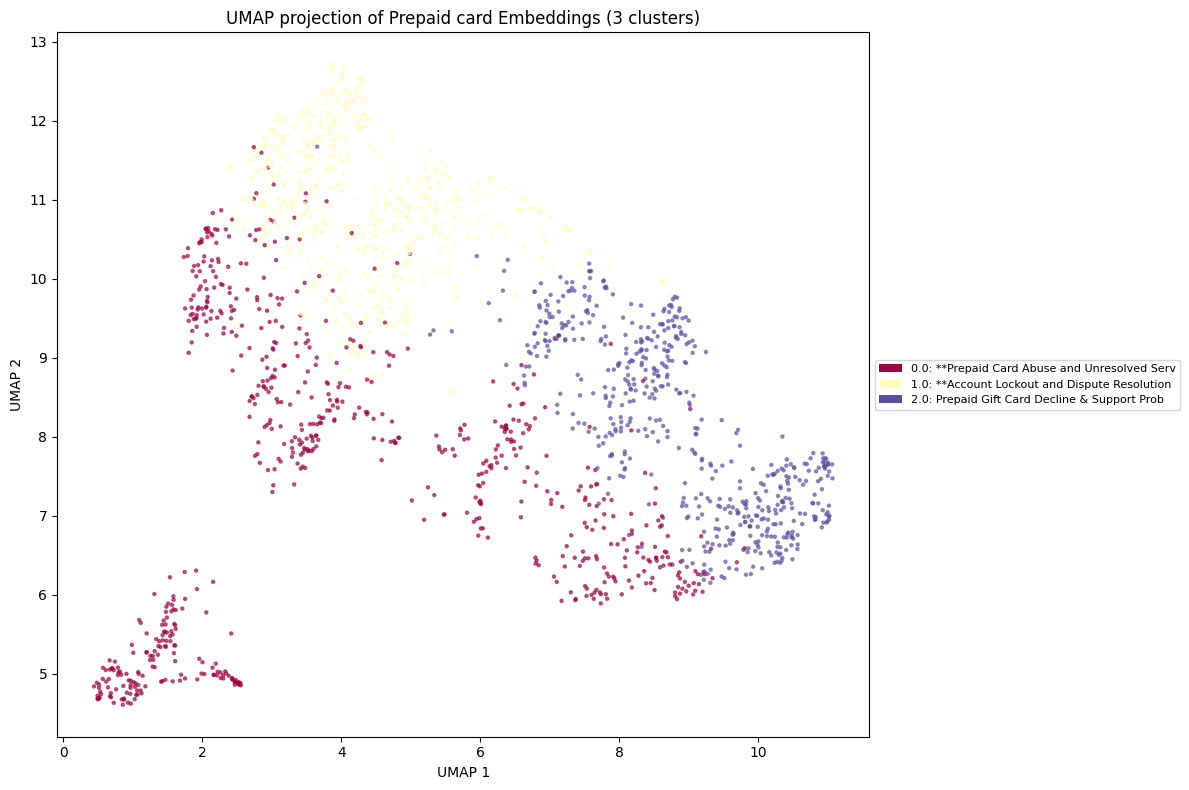

C:\Users\whdgu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


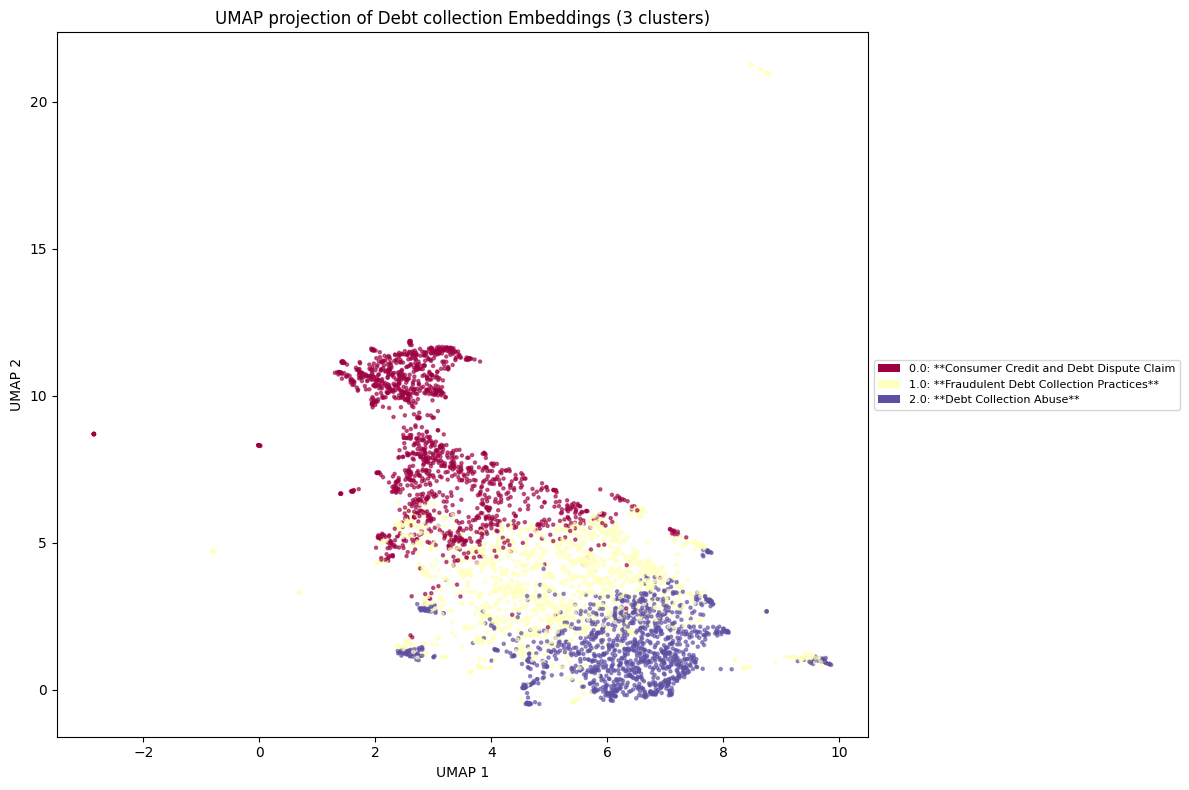

C:\Users\whdgu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


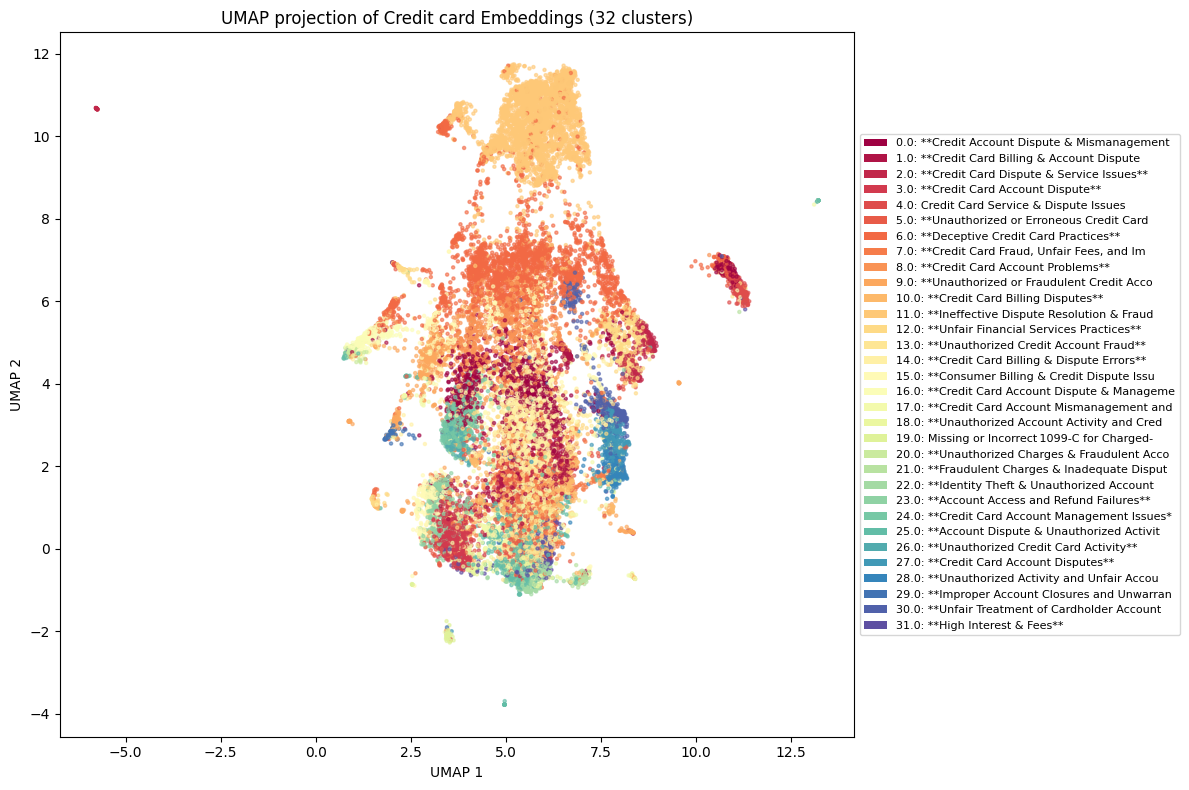

C:\Users\whdgu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


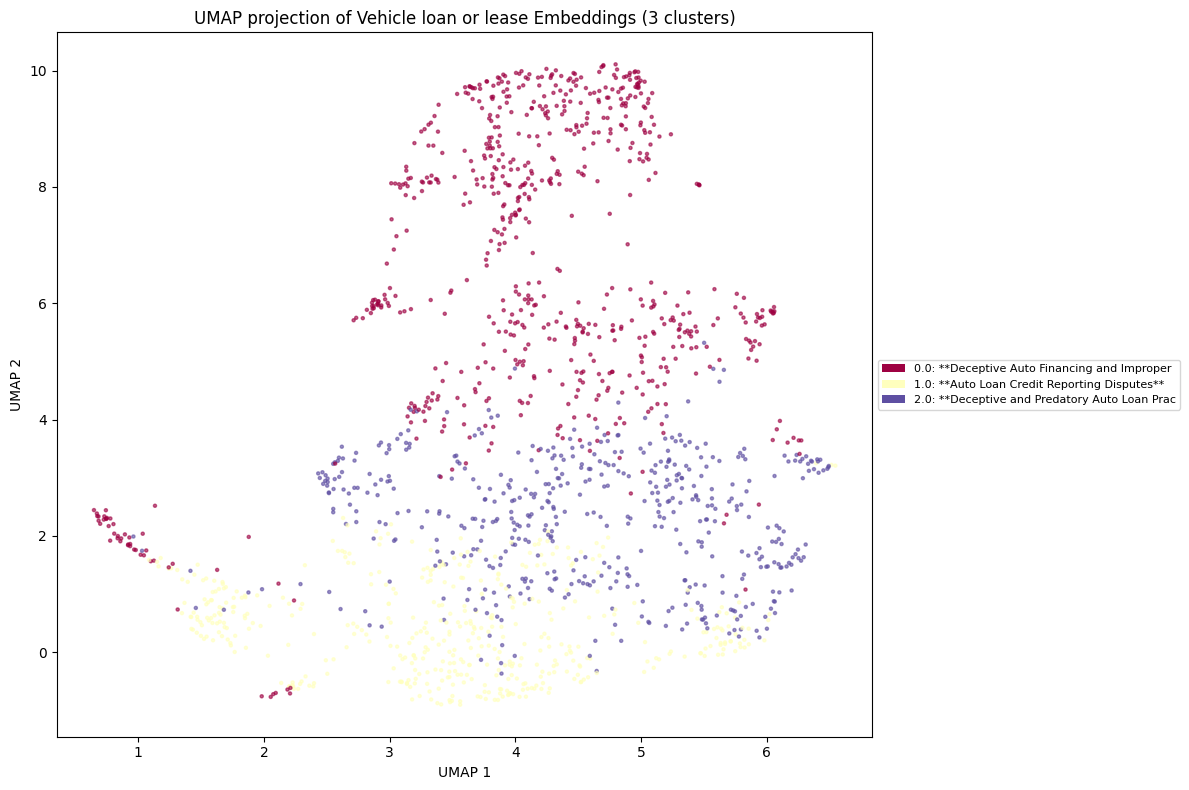

C:\Users\whdgu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


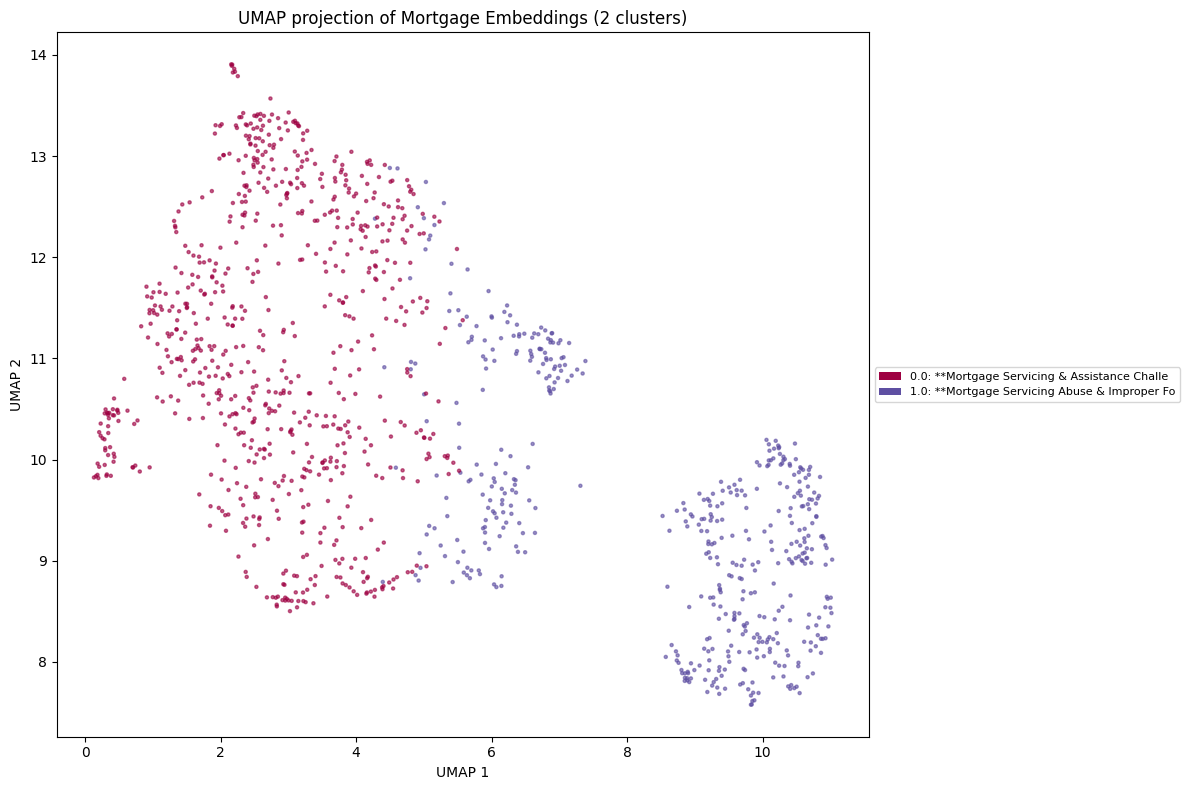

C:\Users\whdgu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


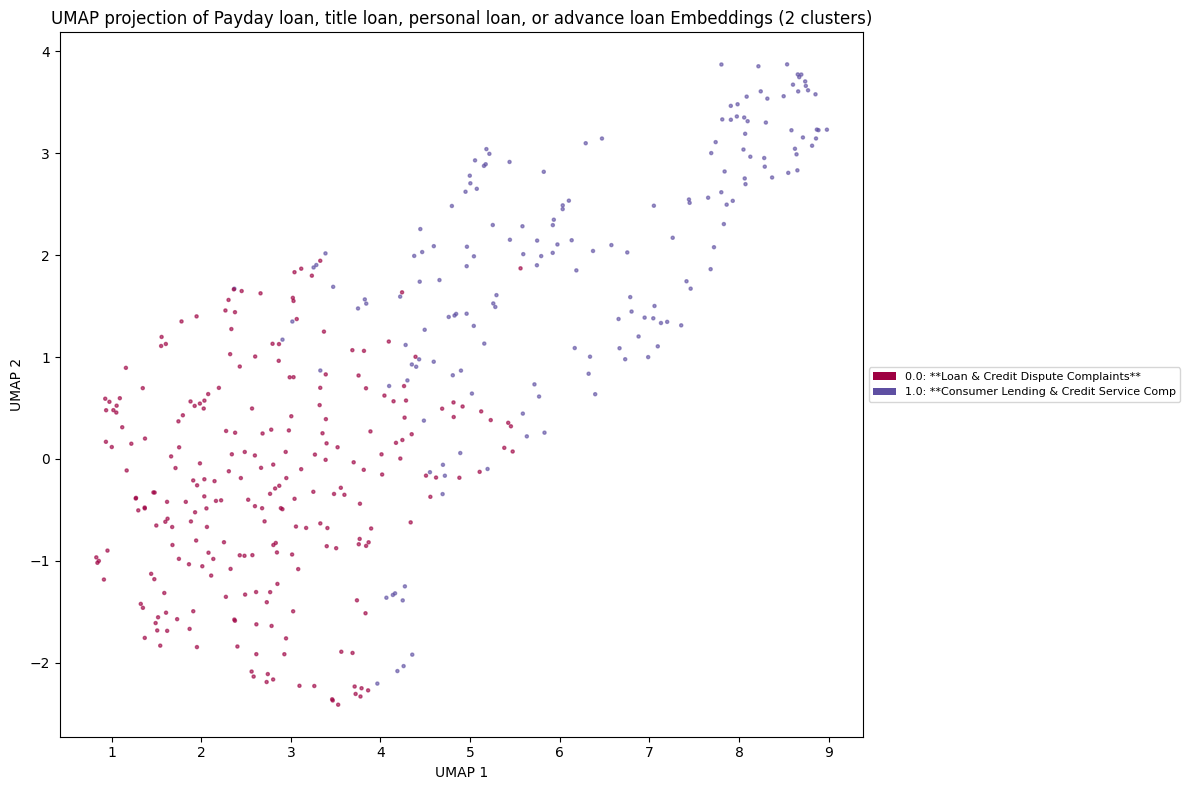

C:\Users\whdgu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


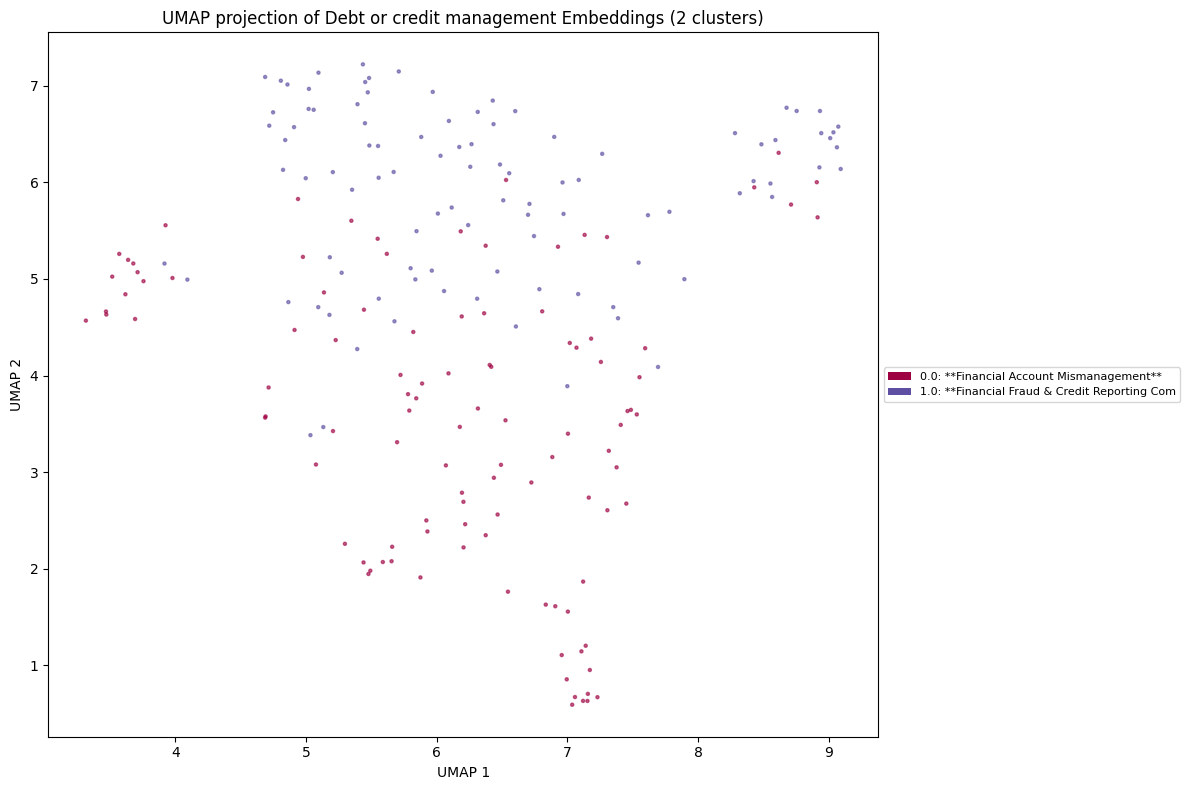

C:\Users\whdgu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


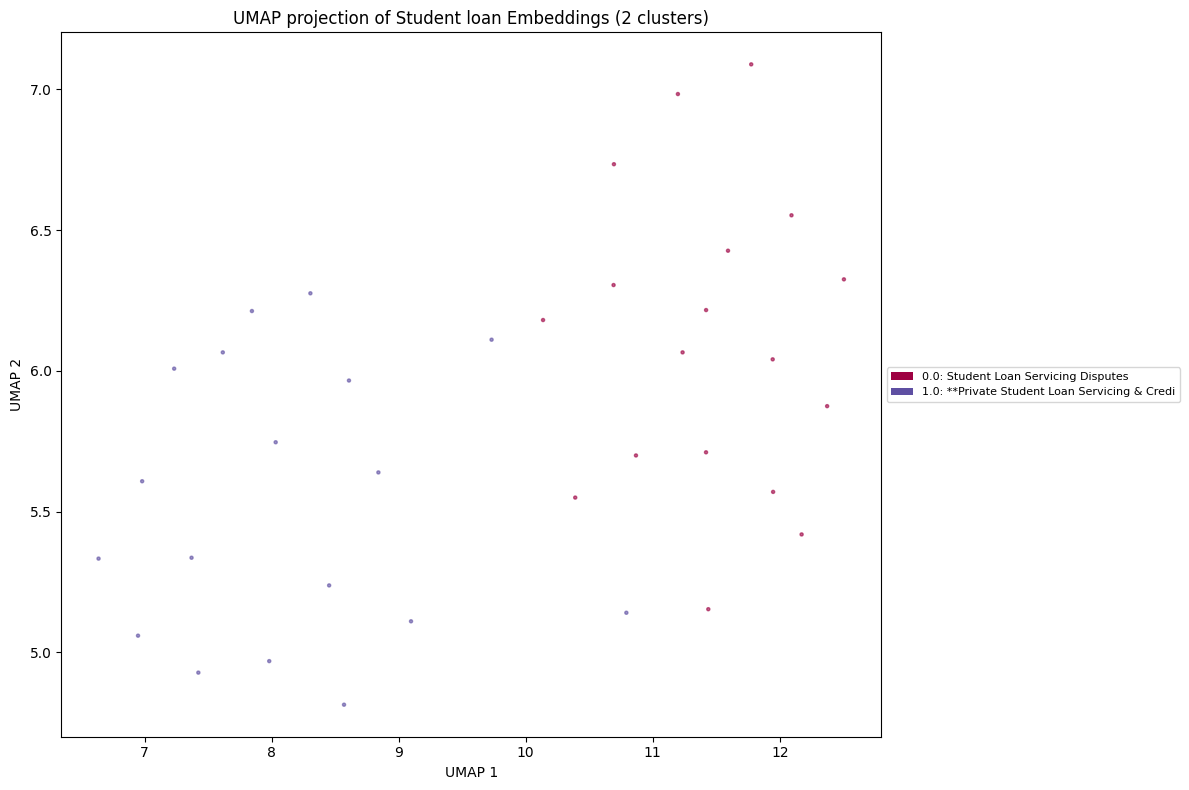

In [4]:
# run umap on embeddings and plot clusters
import umap
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

#convert embeddings to numpy array
#embeddinngs are col 0 to 383
for product in embeddings_df['product'].unique():
    product_mask = embeddings_df['product'] == product
    product_embeddings = embeddings_df.loc[product_mask, embeddings_df.columns[:-11]].values
    cluster_labels = embeddings_df.loc[product_mask, 'agglomerative_cluster'].values
    cluster_names = embeddings_df.loc[product_mask, 'cluster_name'].values
    
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42, init='random')
    embedding_2d = reducer.fit_transform(product_embeddings)
    
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=cluster_labels, cmap='Spectral', s=5, alpha=0.6)
    
    # Create legend with cluster names (limit to first 50)
    unique_clusters = np.unique(cluster_labels)
    cluster_to_name = {}
    for cluster in unique_clusters:
        idx = np.where(cluster_labels == cluster)[0][0]
        cluster_to_name[cluster] = cluster_names[idx]
    
    # Show only first 50 clusters in legend
    legend_elements = []
    for i, cluster in enumerate(sorted(unique_clusters)[:50]):
        color = plt.cm.Spectral(i / max(len(unique_clusters) - 1, 1))
        # Handle missing or NaN cluster names
        cluster_name = cluster_to_name.get(cluster, "Unnamed")
        if pd.isna(cluster_name):
            cluster_name = "Unnamed"
        cluster_name_str = str(cluster_name)[:40]
        legend_elements.append(Patch(facecolor=color, label=f"{cluster}: {cluster_name_str}"))
    
    if len(unique_clusters) > 50:
        legend_elements.append(Patch(facecolor='white', label=f"... and {len(unique_clusters) - 50} more clusters"))
    
    plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
    plt.title(f'UMAP projection of {product} Embeddings ({len(unique_clusters)} clusters)')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.tight_layout()
    plt.savefig(f'plots/umap_{product.replace("/", "_").replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
!pip install umap-learn